# Notebook to Analyze NER Results

In [14]:
import duckdb
import pandas as pd


In [ ]:
import numpy as np

embeddings = np.load("../models/embeddings.npy")
print(embeddings.shape)  # should be (24660, 384) for all-MiniLM-L6-v

FileNotFoundError: [Errno 2] No such file or directory: 'models/embeddings.npy'

# Count Entities and Articles with Found Entities

In [29]:
con = duckdb.connect("../../guardian_articles.duckdb")

count_spacy = con.execute(
    """
    SELECT COUNT (*) as count
    FROM article_entities_spacy
    """
).df()
print(f"The spaCy model finds {count_spacy.at[0, 'count']:,} entities.")

count_distinct_spacy = con.execute(
    """
    SELECT COUNT(DISTINCT id) as distinct_count FROM article_entities_spacy
    """
).df()
print(
    f"The spaCy model found entities in {count_distinct_spacy.at[0, 'distinct_count']:,} distinct articles."
)
count_bert = con.execute(
    """
    SELECT COUNT (*) as count
    FROM article_entities_bert
    """
).df()
print(f"The BERT NER model finds {count_bert.at[0, 'count']:,} entities.")
count_distinct_bert = con.execute(
    """
    SELECT COUNT(DISTINCT id) as distinct_count FROM article_entities_bert
    """
).df()
print(
    f"The BERT NER model found entities in {count_distinct_bert.at[0, 'distinct_count']:,} distinct articles."
)
print(
    "There is a 30 article gap in the number of articles found with entities between the two models. The BERT NER model found entities in 30 fewer articles."
)

The spaCy model finds 3,972,804 entities.
The spaCy model found entities in 24,657 distinct articles.
The BERT NER model finds 693,154 entities.
The BERT NER model found entities in 24,627 distinct articles.
There is a 30 article gap in the number of articles found with entities between the two models. The BERT NER model found entities in 30 fewer articles.


# Review Table Schema

In [56]:
# return table schemas
con = duckdb.connect("../../guardian_articles.duckdb")

print(
    "This is my table structure for the article_entities_spacy table which stores the entities from the spACy model."
)
describe_spacy = con.execute(
    """
    DESCRIBE article_entities_spacy
    """
).df()
print(describe_spacy)

This is my table structure for the article_entities_spacy table which stores the entities from the spACy model.
    column_name column_type null   key default extra
0            id     VARCHAR  YES  None    None  None
1   entity_text     VARCHAR  YES  None    None  None
2  entity_label     VARCHAR  YES  None    None  None
3    start_char     INTEGER  YES  None    None  None
4      end_char     INTEGER  YES  None    None  None


In [38]:
print(
    "This is my table structure for the article_entities_spacy table which stores the entities from the BERT NER model."
)
describe_bert = con.execute(
    """
    DESCRIBE article_entities_bert
    """
).df()
print(describe_bert)

This is my table structure for the article_entities_spacy table which stores the entities from the BERT NER model.
    column_name column_type null   key default extra
0            id     VARCHAR  YES  None    None  None
1   entity_text     VARCHAR  YES  None    None  None
2  entity_label     VARCHAR  YES  None    None  None
3         score       FLOAT  YES  None    None  None
4    start_char     INTEGER  YES  None    None  None
5      end_char     INTEGER  YES  None    None  None


In [55]:
print("These are my top 20 topic labels.")
topic_labels = con.execute(
    """
    SELECT 
        topic_label_clean,
        COUNT(*) as topic_count
    FROM article_topics_labelled
    GROUP BY topic_label_clean
    ORDER BY topic_count DESC 
    LIMIT 20;
    """
).df()
print(topic_labels)

These are my top 20 topic labels.
                      topic_label_clean  topic_count
0               Government and Politics        13766
1                         Uncategorized         7883
2                     Football & Soccer          926
3                              Olympics          136
4                                 Sleep          110
5                       Google Products          106
6                       Christmas Trees           80
7                       Classical Music           47
8                             Formula 1           36
9                            Basketball           34
10                    Cosmetic Products           34
11                            Dinosaurs           33
12       The NHS and British Healthcare           33
13                    Space Exploration           32
14                               Poetry           31
15                          Middle East           30
16        Night and Nocturnal Creatures           30
17          

# Calculating NER Agreement Between the Two Models

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

df_agreement = con.execute("""
WITH spacy_entities AS (
    SELECT 
        id,
        LIST(LOWER(entity_text)) as spacy_entities
    FROM article_entities_spacy
    GROUP BY id
),
bert_entities AS (
    SELECT 
        id,
        LIST(LOWER(entity_text)) as bert_entities
    FROM article_entities_bert
    GROUP BY id
),
agreement AS (
    SELECT
        s.id,
        -- intersection: entities in both
        LEN(LIST_INTERSECT(s.spacy_entities, b.bert_entities)) as intersection_count,
        -- union: entities in either
        LEN(LIST_DISTINCT(LIST_CONCAT(s.spacy_entities, b.bert_entities))) as union_count,
        -- Jaccard similarity
        CASE 
            WHEN LEN(LIST_DISTINCT(LIST_CONCAT(s.spacy_entities, b.bert_entities))) = 0 THEN 0
            ELSE LEN(LIST_INTERSECT(s.spacy_entities, b.bert_entities))::FLOAT / 
                 LEN(LIST_DISTINCT(LIST_CONCAT(s.spacy_entities, b.bert_entities)))
        END as jaccard_score
    FROM spacy_entities s
    INNER JOIN bert_entities b USING (id)
)
SELECT 
    a.id,
    a.jaccard_score,
    a.intersection_count,
    a.union_count,
    t.topic_label_clean
FROM agreement a
JOIN article_topics_labelled t USING (id)
""").df()

con.close()
print(f"Articles with agreement scores: {len(df_agreement):,}")
print(
    f"\nMean Jaccard by topic:\n{df_agreement.groupby('topic_label_clean')['jaccard_score'].mean().sort_values(ascending=False)}"
)

Articles with agreement scores: 24,627

Mean Jaccard by topic:
topic_label_clean
Criminal Investigations           0.258025
Obituaries                        0.251422
Pandas                            0.237168
Saturday Quiz Game                0.233877
Italian Politics                  0.229894
                                    ...   
Gut Health                        0.078449
The NHS and British Healthcare    0.077519
Pac Man                           0.072994
Cosmetic Products                 0.071566
Arguments and Relationships       0.055905
Name: jaccard_score, Length: 117, dtype: float32


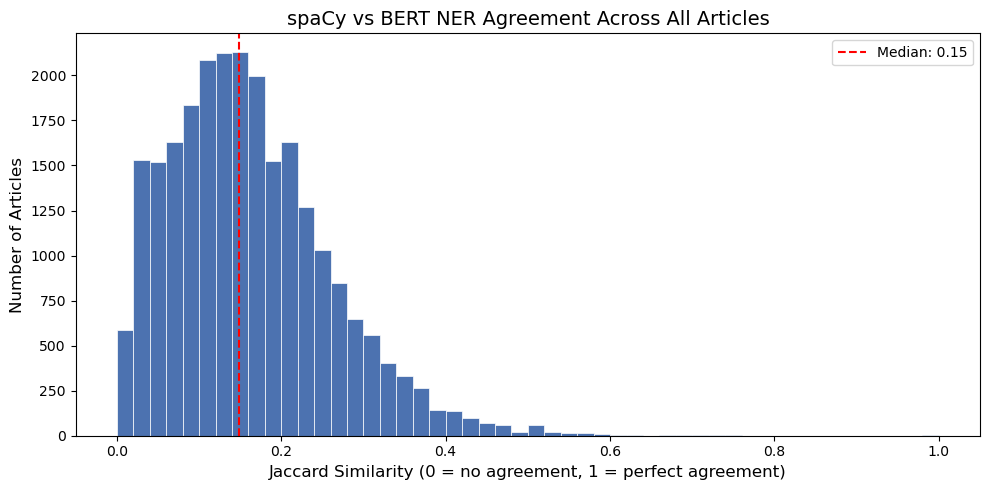

/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_38603/2999039054.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_38603/2999039054.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)


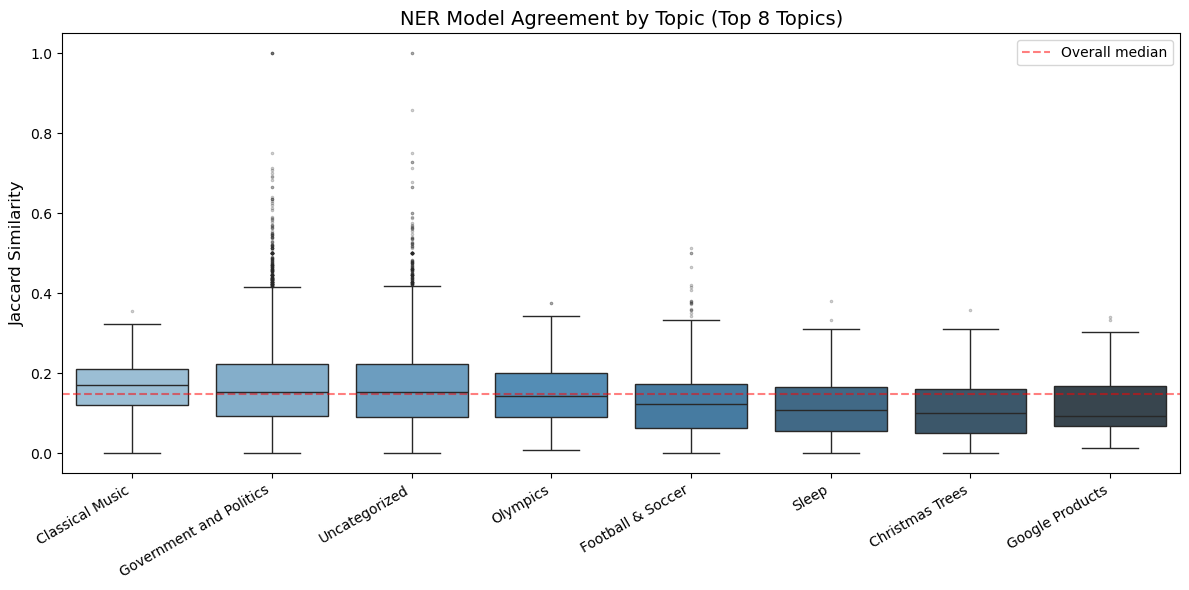

                          Mean  Median  Std Dev  N Articles
topic_label_clean                                          
Government and Politics  0.165   0.153    0.100       13759
Uncategorized            0.165   0.152    0.100        7875
Football & Soccer        0.129   0.122    0.084         921
Olympics                 0.148   0.143    0.079         136
Google Products          0.122   0.094    0.078         106
Sleep                    0.118   0.108    0.083         106
Christmas Trees          0.111   0.100    0.078          80
Classical Music          0.174   0.171    0.073          47


In [60]:
# --- Plot 1: Histogram of agreement scores across all articles ---
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_agreement["jaccard_score"],
    bins=50,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_xlabel(
    "Jaccard Similarity (0 = no agreement, 1 = perfect agreement)", fontsize=12
)
ax.set_ylabel("Number of Articles", fontsize=12)
ax.set_title("spaCy vs BERT NER Agreement Across All Articles", fontsize=14)
ax.axvline(
    df_agreement["jaccard_score"].median(),
    color="red",
    linestyle="--",
    label=f"Median: {df_agreement['jaccard_score'].median():.2f}",
)
ax.legend()

plt.tight_layout()
plt.savefig("plots/ner_agreement_histogram.png", dpi=150)
plt.show()


# --- Plot 2: Box plot by topic (top 8 topics by article count for readability) ---

# Keep only top 8 topics so the plot isn't cramped
top_topics = df_agreement["topic_label_clean"].value_counts().head(8).index.tolist()

df_plot = df_agreement[df_agreement["topic_label_clean"].isin(top_topics)].copy()

# Sort by median agreement for a cleaner plot
topic_order = (
    df_plot.groupby("topic_label_clean")["jaccard_score"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="topic_label_clean",
    y="jaccard_score",
    order=topic_order,
    palette="Blues_d",
    ax=ax,
    flierprops={"marker": ".", "alpha": 0.3, "markersize": 3},  # tone down outlier dots
)

ax.set_xlabel("")
ax.set_ylabel("Jaccard Similarity", fontsize=12)
ax.set_title("NER Model Agreement by Topic (Top 8 Topics)", fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.axhline(
    df_agreement["jaccard_score"].median(),
    color="red",
    linestyle="--",
    alpha=0.5,
    label="Overall median",
)
ax.legend()

plt.tight_layout()
plt.savefig("plots/ner_agreement_by_topic.png", dpi=150)
plt.show()


# --- Table: Summary stats by topic for report ---
summary = (
    df_agreement[df_agreement["topic_label_clean"].isin(top_topics)]
    .groupby("topic_label_clean")["jaccard_score"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
    .sort_values("count", ascending=False)
    .rename(
        columns={
            "mean": "Mean",
            "median": "Median",
            "std": "Std Dev",
            "count": "N Articles",
        }
    )
)
print(summary.to_string())

# Top 20 most frequent entities per model (table)


In [66]:
con = duckdb.connect("../../guardian_articles.duckdb")

# spaCy PERSON entities — label is 'PERSON'
df_spacy = con.execute("""
    SELECT 
        entity_text,
        COUNT(*) as count
    FROM article_entities_spacy
    WHERE entity_label = 'PERSON'
    AND LENGTH(entity_text) > 2  -- filter out single letters/noise
    GROUP BY entity_text
    ORDER BY count DESC
    LIMIT 20
""").df()

# BERT PERSON entities — label is 'PER'
df_bert = con.execute("""
    SELECT 
        entity_text,
        COUNT(*) as count
    FROM article_entities_bert
    WHERE entity_label = 'PER'
    AND LENGTH(entity_text) > 2
    GROUP BY entity_text
    ORDER BY count DESC
    LIMIT 20
""").df()

con.close()

# Build side by side table
df_table = pd.DataFrame(
    {
        "Rank": range(1, 21),
        "spaCy Entity": df_spacy["entity_text"].values,
        "spaCy Count": df_spacy["count"].values,
        "BERT Entity": df_bert["entity_text"].values,
        "BERT Count": df_bert["count"].values,
    }
)

print(df_table.to_string(index=False))

 Rank     spaCy Entity  spaCy Count    BERT Entity  BERT Count
    1     Donald Trump        11929          Trump       10391
    2           Brexit         6826   Donald Trump        3077
    3            Biden         6154          Putin         828
    4          Starmer         5785         ##iden         779
    5            Trump         4287        Johnson         744
    6          Johnson         4061           ##sk         651
    7            Putin         3857         Donald         613
    8     Keir Starmer         3788   ##ir Starmer         613
    9         Albanese         3783  Boris Johnson         586
   10        Joe Biden         3484      Joe Biden         548
   11 Anthony Albanese         3406           John         468
   12            Covid         3402          David         454
   13            Sunak         3230 Vladimir Putin         410
   14   Donald Trump’s         2546         Harris         409
   15    Boris Johnson         2372      ##on Musk     

I found weaknesses of both approaches. Both models appear to identifiy entities that are not actually people as "PERSON" entities. In the top 20 spaCy "PERSON" entities, we observe that "Brexit", "Covid", and "Tory" all appear. In the top 20 BERT "PERSON" entities, we observe "Sun". 

The BERT model uses subword tokenization. The "##" tokens are BERT subword artifacts that result from WordPiece tokenization which splits unknown words into subword pieces. The `aggregation_strategy="simple"` approach appeared to fail in the pipeline. Not all subword tokens were successfully merged into complete words (names in this case), resulting in these tokenized names appearing in the final dataset. I intentially did not perform post-processing filtering to display this difference, although for production I would choose to clean these entities before integrating them in the NER search function on the platform. 

# Below is Work in Progress

In [30]:
unique_test = con.execute(
    """
    SELECT COUNT(DISTINCT id) FROM article_topics
    """
).df()
print(unique_test)

   count(DISTINCT id)
0               24660


In [31]:
count_labelled = con.execute(
    """
    SELECT COUNT(DISTINCT id) FROM article_topics_labelled;

    """
).df()
print(count_labelled)

   count(DISTINCT id)
0               24660


In [32]:
spacy_entities = con.execute(
    """
    SELECT entity_label, COUNT(*) as count
FROM article_entities_spacy
GROUP BY entity_label
ORDER BY count DESC;
    """
).df()
print(spacy_entities)

   entity_label   count
0           ORG  875716
1        PERSON  818377
2           GPE  594760
3          DATE  560123
4      CARDINAL  422891
5          NORP  214839
6       ORDINAL   80785
7          TIME   72737
8       PERCENT   70020
9         MONEY   61935
10          LOC   54530
11  WORK_OF_ART   34839
12      PRODUCT   34168
13          FAC   26608
14     QUANTITY   22379
15        EVENT   17981
16          LAW    6217
17     LANGUAGE    3899


In [33]:
entity_check_person = con.execute(
    """
    SELECT entity_text, COUNT(*) as count
FROM article_entities_spacy
WHERE entity_label = 'PERSON'
GROUP BY entity_text
ORDER BY count DESC
LIMIT 20;
    """
).df()

print(entity_check_person)

         entity_text  count
0       Donald Trump  11929
1             Brexit   6826
2              Biden   6154
3            Starmer   5785
4              Trump   4287
5            Johnson   4061
6              Putin   3857
7       Keir Starmer   3788
8           Albanese   3783
9          Joe Biden   3484
10  Anthony Albanese   3406
11             Covid   3402
12             Sunak   3230
13    Donald Trump’s   2546
14     Boris Johnson   2372
15              Tory   2189
16         Elon Musk   2154
17    Vladimir Putin   1984
18       Rishi Sunak   1950
19            Reeves   1925


In [34]:
entity_check_org = con.execute(
    """
    SELECT entity_text, COUNT(*) as count
FROM article_entities_spacy
WHERE entity_label = 'ORG'
GROUP BY entity_text
ORDER BY count DESC
LIMIT 20;
    """
).df()

print(entity_check_org)

   entity_text  count
0          BST  49615
1        Trump  39233
2           AI  30923
3          GMT  16078
4     Guardian  13740
5           EU  12743
6   BST         12339
7       Labour  10887
8     BST       10841
9       Google   8567
10       Labor   7426
11    Facebook   7331
12      Senate   6599
13         NHS   5491
14     Reuters   5071
15      Amazon   5009
16         BBC   4496
17         NSW   4281
18       House   4275
19          UN   4146


In [35]:
con.close()

# Checking BERT Results

In [22]:
con = duckdb.connect("../../guardian_articles.duckdb")


In [23]:
count_article_entities_bert = con.execute(
    """
    SELECT COUNT (*) 
    FROM article_entities_bert
    """
).df()
print(count_article_entities_bert)

   count_star()
0        693154


In [24]:
unique_rows_bert = con.execute(
    """
    SELECT COUNT(DISTINCT id) FROM article_entities_bert
    """
).df()
print(unique_rows_bert)

   count(DISTINCT id)
0               24627


In [25]:
# there are 30 more articles that spaCy found entities than bert.
# could query those specifically

# SELECT DISTINCT s.id
# FROM article_entities_spacy s
# LEFT JOIN article_entities_bert b USING (id)
# WHERE b.id IS NULL;

# then can spot-check a few of those articles to see why this is
# could be short opinion pieces, or data-heavy article with few proper nouns
# can include this in the analysis

In [ ]:
con.close()